In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

Importing plotly failed. Interactive plots will not work.


In [2]:
# LOAD PREPROCESSED DATASET

df = pd.read_csv("../data/preprocessed_data.csv")

df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,Season
0,109318,C,7,80.079844,2025-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2025,12,26,52,4,Friday,False,Winter
1,993229,C,4,75.195229,2025-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2025,8,5,32,3,Tuesday,False,Monsoon
2,579675,A,8,31.528816,2026-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2026,3,11,11,1,Wednesday,False,Summer
3,799826,D,5,98.880218,2025-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2025,10,27,44,4,Monday,False,Autumn
4,121413,A,7,93.188512,2025-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2025,12,22,52,4,Monday,False,Winter


In [3]:
# CONVERT DATE COLUMN

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],format="mixed")

In [4]:
# CREATE DAILY SALES DATASET

daily_sales = df.groupby("TransactionDate")["TotalAmount"].sum().reset_index()

daily_sales.head()

,TransactionDate,TotalAmount
0,2025-04-29 22:27:00,176.102880
1,2025-04-29 22:29:00,416.546875
2,2025-04-29 22:39:00,216.950602
3,2025-04-29 22:45:00,426.845208
4,2025-04-29 22:53:00,101.662372


In [5]:
# PREPARE DATA FOR PROPHET

daily_sales.rename(
    columns={
        "TransactionDate":"ds",
        "TotalAmount":"y"
    },
    inplace=True
)

daily_sales.head()

,ds,y
0,2025-04-29 22:27:00,176.102880
1,2025-04-29 22:29:00,416.546875
2,2025-04-29 22:39:00,216.950602
3,2025-04-29 22:45:00,426.845208
4,2025-04-29 22:53:00,101.662372


In [6]:
# TRAIN TEST SPLIT

split = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split]

test = daily_sales.iloc[split:]

print("Training Records :", len(train))
print("Testing Records :", len(test))

Training Records : 72786
Testing Records : 18197


In [7]:
# TRAIN PROPHET MODEL

model = Prophet()

model.fit(train)

print("Model Trained Successfully!")

16:59:18 - cmdstanpy - INFO - Chain [1] start processing
16:59:30 - cmdstanpy - INFO - Chain [1] done processing


Model Trained Successfully!


In [8]:
# CREATE FUTURE DATAFRAME

future = model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

future.tail()

,ds
90978,2075-12-08 23:29:00
90979,2075-12-09 23:29:00
90980,2075-12-10 23:29:00
90981,2075-12-11 23:29:00
90982,2075-12-12 23:29:00


In [9]:
# FORECAST

forecast = model.predict(future)

forecast[["ds","yhat"]].tail()

,ds,yhat
90978,2075-12-08 23:29:00,-1222.431781
90979,2075-12-09 23:29:00,-1227.204156
90980,2075-12-10 23:29:00,-1227.543089
90981,2075-12-11 23:29:00,-1227.670939
90982,2075-12-12 23:29:00,-1231.421251


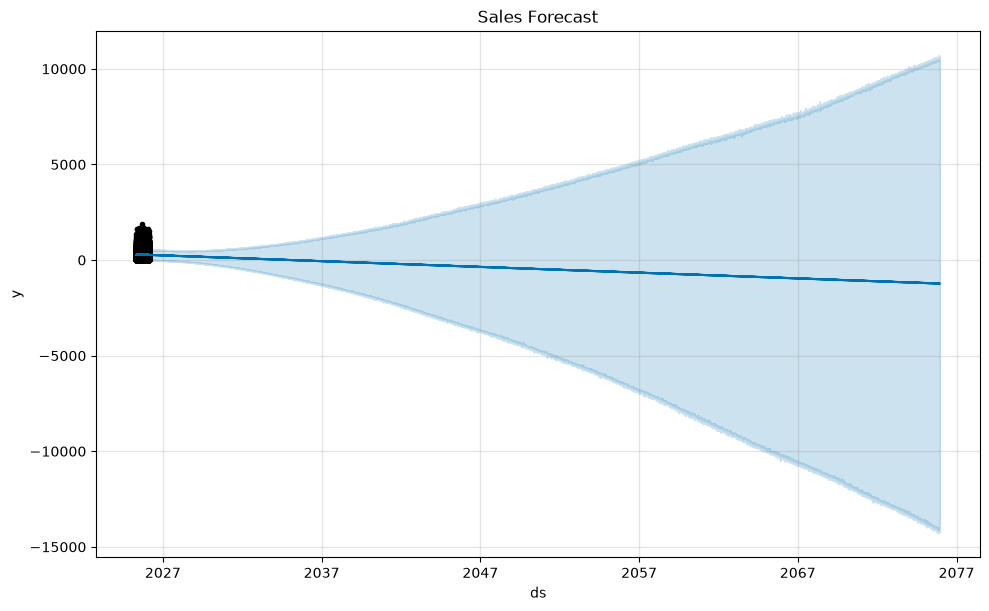

In [10]:
# FORECAST PLOT

fig = model.plot(forecast)

plt.title("Sales Forecast")

plt.show()

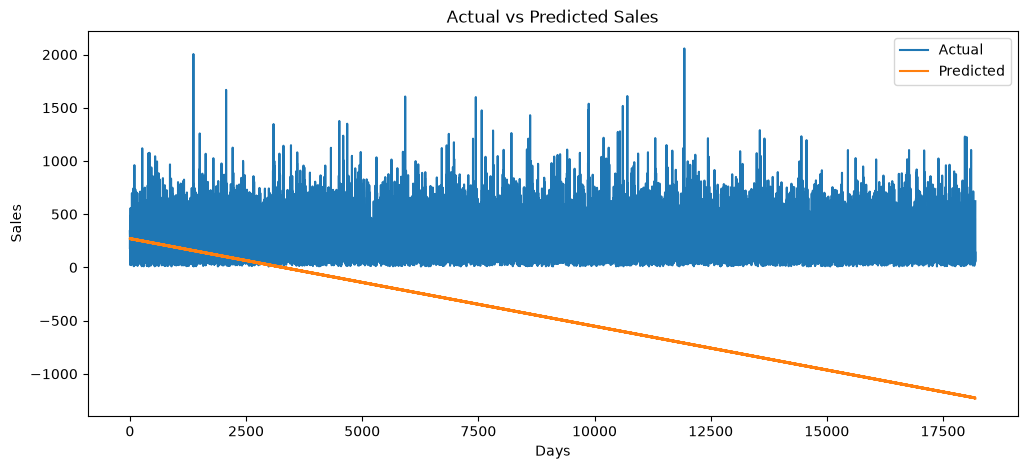

In [11]:
# ACTUAL VS PREDICTED

predicted = forecast[["ds","yhat"]].tail(len(test)).reset_index(drop=True)

actual = test.reset_index(drop=True)

plt.figure(figsize=(12,5))

plt.plot(actual["y"], label="Actual")

plt.plot(predicted["yhat"], label="Predicted")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Days")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [12]:
# MODEL EVALUATION

mae = mean_absolute_error(
    actual["y"],
    predicted["yhat"]
)

rmse = mean_squared_error(
    actual["y"],
    predicted["yhat"]
) ** 0.5

print("MAE =", round(mae,2))
print("RMSE =", round(rmse,2))

MAE = 759.54
RMSE = 889.24


In [13]:
# CHECK MODEL BEFORE SAVING

future = model.make_future_dataframe(periods=5)

forecast = model.predict(future)

print(forecast[["ds","yhat"]].tail())

                       ds        yhat
72786 2026-02-16 23:29:00  270.095092
72787 2026-02-17 23:29:00  269.756159
72788 2026-02-18 23:29:00  269.628309
72789 2026-02-19 23:29:00  265.877996
72790 2026-02-20 23:29:00  269.921899


In [14]:
# SAVE MODEL

joblib.dump(
    model,
    "../models/prophet_sales_forecast.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [15]:
# FORECAST NEXT 30 DAYS

future_30 = model.make_future_dataframe(
    periods=30,
    freq="D"
)

forecast_30 = model.predict(future_30)

forecast_30[["ds","yhat"]].tail(30)

,ds,yhat
72786,2026-02-16 23:29:00,270.095092
72787,2026-02-17 23:29:00,269.756159
72788,2026-02-18 23:29:00,269.628309
72789,2026-02-19 23:29:00,265.877996
72790,2026-02-20 23:29:00,269.921899
72791,2026-02-21 23:29:00,270.422887
72792,2026-02-22 23:29:00,274.291360
72793,2026-02-23 23:29:00,269.518986
72794,2026-02-24 23:29:00,269.180053
72795,2026-02-25 23:29:00,269.052203


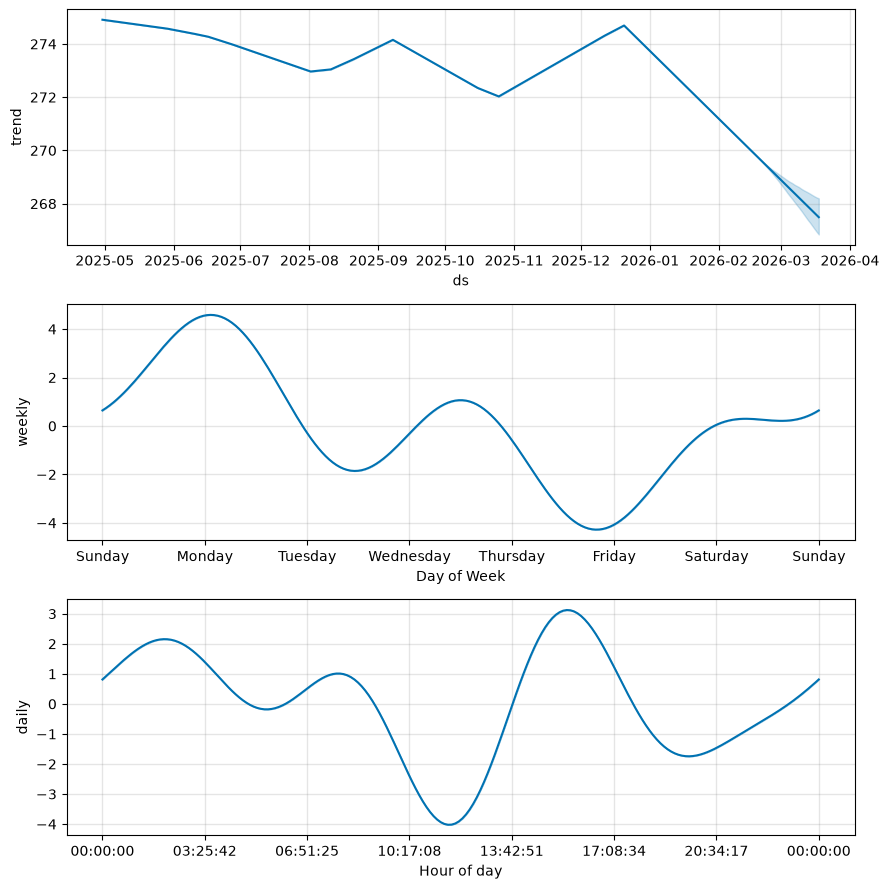

In [16]:
# FORECAST COMPONENTS

fig = model.plot_components(forecast_30)

plt.show()

In [17]:
## Model Evaluation Summary

'''Model Used:
- Prophet

Evaluation Metrics:
- MAE
- RMSE

Limitations:
- Forecast is based only on historical sales.
- External factors such as promotions, holidays, weather and inventory are not included.
- This serves as a baseline forecasting prototype for Milestone 1.

Future Scope:
- Random Forest
- XGBoost
- Customer Segmentation
- Recommendation System
'''


'Model Used:\n- Prophet\n\nEvaluation Metrics:\n- MAE\n- RMSE\n\nLimitations:\n- Forecast is based only on historical sales.\n- External factors such as promotions, holidays, weather and inventory are not included.\n- This serves as a baseline forecasting prototype for Milestone 1.\n\nFuture Scope:\n- Random Forest\n- XGBoost\n- Customer Segmentation\n- Recommendation System\n'

In [18]:
# MODEL EVALUATION

'''The baseline forecasting model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
Evaluation Metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
The obtained metrics provide a baseline performance for future comparison with advanced machine learning models.
'''

'The baseline forecasting model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).\nEvaluation Metrics:\n\n- Mean Absolute Error (MAE)\n- Root Mean Squared Error (RMSE)\nThe obtained metrics provide a baseline performance for future comparison with advanced machine learning models.\n'

In [19]:
# LIMITATIONS

'''- The baseline model relies only on historical sales data.
- External factors such as holidays, promotions and customer behaviour are not considered.
- Inventory availability and product demand are not included.
- The model serves as an initial forecasting prototype and is not intended for production-level forecasting.
'''

'- The baseline model relies only on historical sales data.\n- External factors such as holidays, promotions and customer behaviour are not considered.\n- Inventory availability and product demand are not included.\n- The model serves as an initial forecasting prototype and is not intended for production-level forecasting.\n'

In [20]:
# MILESTONE 2 ROADMAP

'''Future improvements planned for Milestone 2 include:
- Random Forest Regressor
- XGBoost Regressor
- Hyperparameter Tuning
- Feature Engineering
- Model Comparison
- Selection of the best performing forecasting model
'''

'Future improvements planned for Milestone 2 include:\n- Random Forest Regressor\n- XGBoost Regressor\n- Hyperparameter Tuning\n- Feature Engineering\n- Model Comparison\n- Selection of the best performing forecasting model\n'